In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV


In [3]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/breast-cancer.csv')

In [4]:
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [5]:
print (df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Length: 569, dtype: bool

In [7]:
df = df.drop('id', axis=1)

In [8]:
print (df.info())
#df = df.drop(['radius_worst', 'perimeter_worst', 'fractal_dimension_worst'], axis=1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [9]:
print (df.describe())


       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [10]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'].astype(str))

print (df.head(20))
# 1 = M
# 0 = B

    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0           1        17.99         10.38          122.80     1001.0   
1           1        20.57         17.77          132.90     1326.0   
2           1        19.69         21.25          130.00     1203.0   
3           1        11.42         20.38           77.58      386.1   
4           1        20.29         14.34          135.10     1297.0   
5           1        12.45         15.70           82.57      477.1   
6           1        18.25         19.98          119.60     1040.0   
7           1        13.71         20.83           90.20      577.9   
8           1        13.00         21.82           87.50      519.8   
9           1        12.46         24.04           83.97      475.9   
10          1        16.02         23.24          102.70      797.8   
11          1        15.78         17.89          103.60      781.0   
12          1        19.17         24.80          132.40     1123.0   
13    

In [11]:
correlations = df.corr()['diagnosis'].sort_values(ascending=False)
print ("correlations with each feature: ")
print (correlations)

correlations with each feature: 
diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.07

In [12]:
#df = df.drop(['fractal_dimension_se', 'symmetry_se', 'texture_se', 'fractal_dimension_mean', 'smoothness_se'],axis =1)
print (df.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

In [13]:
x = df.drop(['diagnosis'], axis =1)
y = df['diagnosis']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [14]:

model = RandomForestClassifier(random_state =42)
model.fit(x_scaled,y)
importances = model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the most important features
rf_top_features = feature_importance_df['Feature'].head(10).tolist()
print("Top features selected by Random Forest:", rf_top_features)




Top features selected by Random Forest: ['area_worst', 'concave points_worst', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'perimeter_mean', 'concavity_mean', 'area_mean', 'concavity_worst', 'radius_mean']


In [15]:

x = df.drop(['diagnosis'], axis =1)
y = df['diagnosis']
lasso = LassoCV().fit(x_scaled, y)


lasso_coefs = lasso.coef_
lasso_features_df = pd.DataFrame({
    'Feature': x.columns,
    'Lasso_Coefficient': lasso_coefs
}).sort_values(by='Lasso_Coefficient', key=abs, ascending=False)

print("Lasso Feature Coefficients:")
print(lasso_features_df)

# Select features with non-zero coefficients
lasso_top_features = lasso_features_df[lasso_features_df['Lasso_Coefficient'] != 0]['Feature'].tolist()
print("Top features selected by Lasso:", lasso_top_features)


Lasso Feature Coefficients:
                    Feature  Lasso_Coefficient
20             radius_worst           0.550721
23               area_worst          -0.350787
5          compactness_mean          -0.170202
10                radius_se           0.127108
6            concavity_mean           0.102760
16             concavity_se          -0.096273
7       concave points_mean           0.081244
13                  area_se          -0.078541
26          concavity_worst           0.077610
29  fractal_dimension_worst           0.074736
27     concave points_worst           0.050464
21            texture_worst           0.046773
14            smoothness_se           0.045661
17        concave points_se           0.044152
28           symmetry_worst           0.042422
3                 area_mean          -0.025588
1              texture_mean           0.019101
24         smoothness_worst           0.018344
19     fractal_dimension_se          -0.011115
9    fractal_dimension_mean     

e:\OneDrive\Documents\coding\MLInternship\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.002e-02, tolerance: 9.843e-03
  model = cd_fast.enet_coordinate_descent_gram(
e:\OneDrive\Documents\coding\MLInternship\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.353e-02, tolerance: 9.843e-03
  model = cd_fast.enet_coordinate_descent_gram(
e:\OneDrive\Documents\coding\MLInternship\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the f

In [16]:
#Select the top 10 features by absolute coefficient value from Lasso
lasso_top10_features = lasso_features_df.head(10)['Feature'].tolist()
print("Top 10 features selected by Lasso (by absolute coefficient value):", lasso_top10_features)


Top 10 features selected by Lasso (by absolute coefficient value): ['radius_worst', 'area_worst', 'compactness_mean', 'radius_se', 'concavity_mean', 'concavity_se', 'concave points_mean', 'area_se', 'concavity_worst', 'fractal_dimension_worst']


In [17]:
selected_features = list(set(rf_top_features) & set(lasso_top_features))
print("Final selected features (intersection):", selected_features)

# Filter X with selected features
x_selected = x[selected_features]

Final selected features (intersection): ['area_worst', 'concavity_mean', 'concavity_worst', 'concave points_worst', 'concave points_mean', 'radius_worst', 'area_mean']


In [18]:
# Remove outliers from selected features using IQR method
filtered_df = df.copy()
for col in selected_features:
    Q1 = filtered_df[col].quantile(0.25)
    Q3 = filtered_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)]

# Update x_selected and y after outlier removal
x_selected = filtered_df[selected_features]
y = filtered_df['diagnosis']
print('Shape after outlier removal:', x_selected.shape)




Shape after outlier removal: (459, 7)


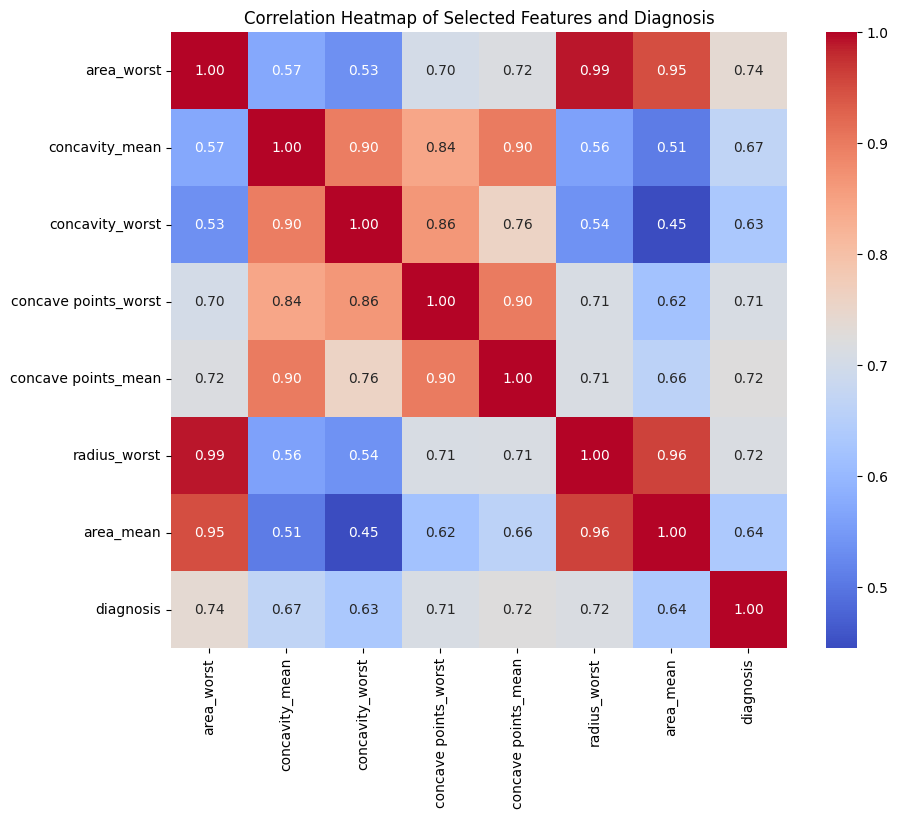

In [19]:
# Correlation heatmap for selected features
plt.figure(figsize=(10, 8))
selected_corr = filtered_df[selected_features + ['diagnosis']].corr()
sns.heatmap(selected_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Selected Features and Diagnosis')
plt.show()

In [20]:
'''
x = df.drop(['diagnosis'], axis =1)
y = df['diagnosis']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)
'''

"\nx = df.drop(['diagnosis'], axis =1)\ny = df['diagnosis']\nscaler = StandardScaler()\nx_scaled = scaler.fit_transform(x)\n\nprint (x)\n"

In [21]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=10))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}



In [22]:
X_train, X_test, y_train, y_test = train_test_split(x_selected, y, test_size=0.2, random_state=42)

In [23]:

k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")

K=1: Test Accuracy = 0.9022
K=2: Test Accuracy = 0.9022
K=3: Test Accuracy = 0.9239
K=4: Test Accuracy = 0.9130
K=5: Test Accuracy = 0.9239
K=6: Test Accuracy = 0.9130
K=7: Test Accuracy = 0.9348
K=8: Test Accuracy = 0.9239
K=9: Test Accuracy = 0.9239
K=10: Test Accuracy = 0.9348
K=11: Test Accuracy = 0.9348
K=12: Test Accuracy = 0.9457
K=13: Test Accuracy = 0.9457
K=14: Test Accuracy = 0.9457
K=15: Test Accuracy = 0.9348
K=16: Test Accuracy = 0.9457
K=17: Test Accuracy = 0.9348
K=18: Test Accuracy = 0.9348
K=19: Test Accuracy = 0.9239
K=20: Test Accuracy = 0.9348
Best K: 12 with accuracy 0.9457


In [24]:

param_grid = {'clf__max_depth': range(1, 21)}

dt_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best max_depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_dt = grid_search.best_estimator_
test_acc = best_dt.score(X_test, y_test)
print(f"Test set accuracy with best max_depth: {test_acc:.4f}")

Best max_depth: 2
Best cross-validated accuracy: 0.9211
Test set accuracy with best max_depth: 0.9565


In [25]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9673
DecisionTree testing accuracy: 0.9457
------------------------------
KNN training accuracy: 0.9510
KNN testing accuracy: 0.9348
------------------------------
Naive-Bayes training accuracy: 0.9210
Naive-Bayes testing accuracy: 0.9239
------------------------------


In [26]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} prediction accuracy on test set: {acc:.4f}")

DecisionTree prediction accuracy on test set: 0.9457
KNN prediction accuracy on test set: 0.9348
Naive-Bayes prediction accuracy on test set: 0.9239


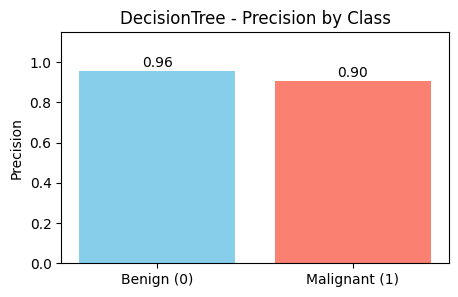

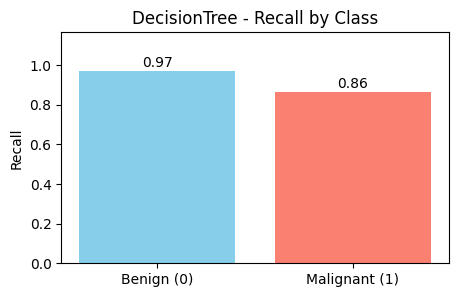

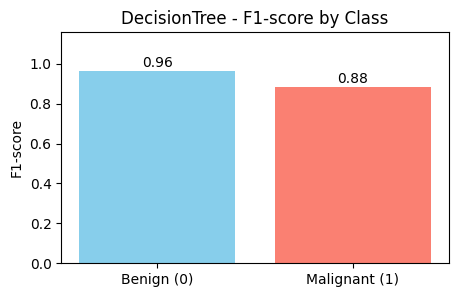

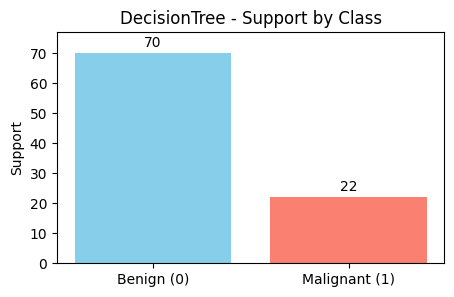

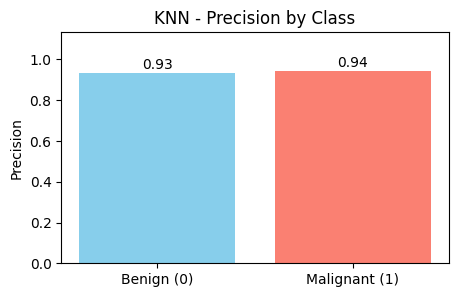

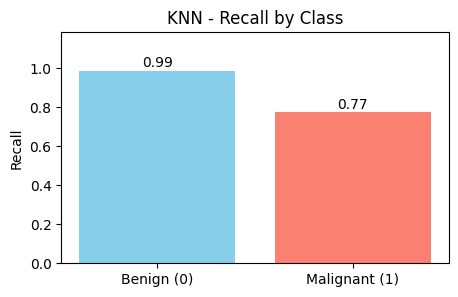

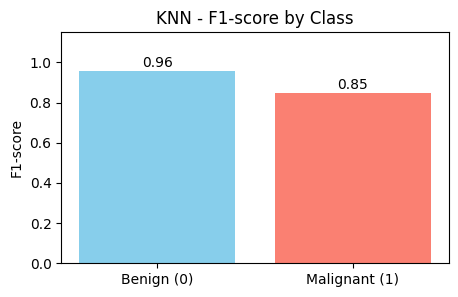

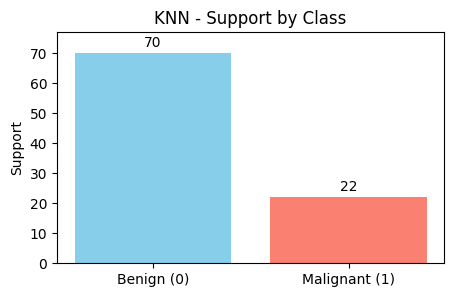

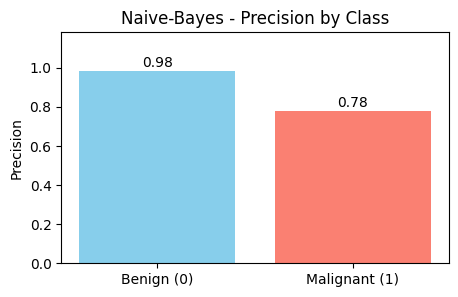

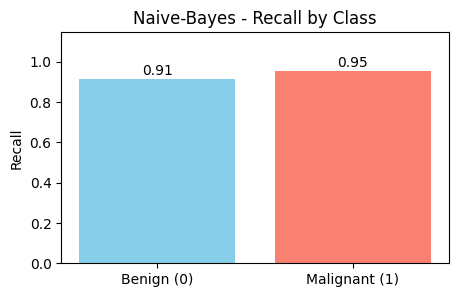

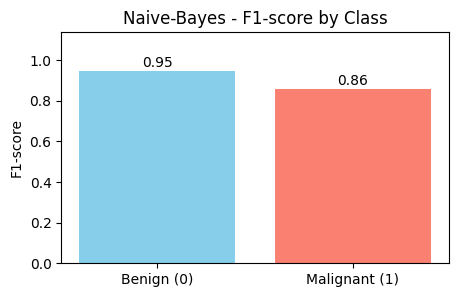

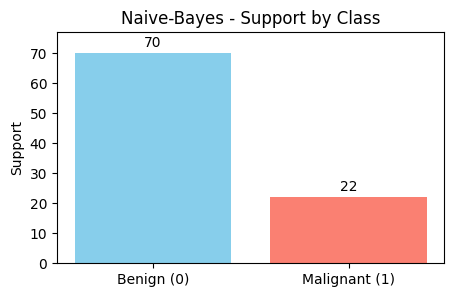

In [27]:

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"], output_dict=True)
    metrics = ['precision', 'recall', 'f1-score', 'support']
    classes = ["Benign (0)", "Malignant (1)"]
    for metric in metrics:
        values = [report[cls][metric] for cls in classes]
        plt.figure(figsize=(5,3))
        plt.bar(classes, values, color=['skyblue', 'salmon'])
        plt.title(f'{name} - {metric.capitalize()} by Class')
        plt.ylabel(metric.capitalize())
        plt.ylim(0, max(values)*1.2 if metric != 'support' else max(values)*1.1)
        for i, v in enumerate(values):
            plt.text(i, v + (0.02 if metric != 'support' else 2), f'{v:.2f}' if metric != 'support' else f'{int(v)}', ha='center')
        plt.show()


Confusion Matrix for DecisionTree:


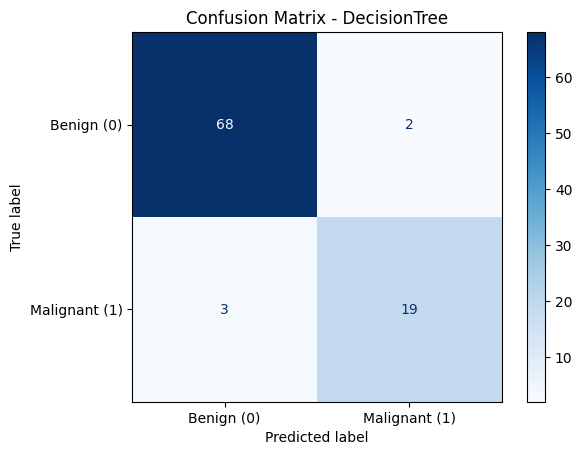

Classification Report for DecisionTree:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.97      0.96        70
Malignant (1)       0.90      0.86      0.88        22

     accuracy                           0.95        92
    macro avg       0.93      0.92      0.92        92
 weighted avg       0.95      0.95      0.95        92

--------------------------------------------------
Confusion Matrix for KNN:


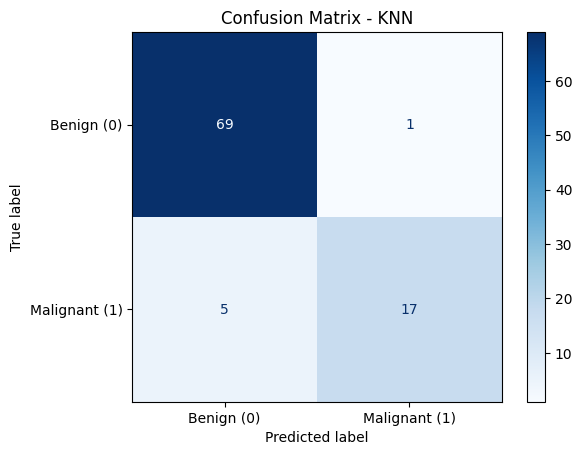

Classification Report for KNN:
               precision    recall  f1-score   support

   Benign (0)       0.93      0.99      0.96        70
Malignant (1)       0.94      0.77      0.85        22

     accuracy                           0.93        92
    macro avg       0.94      0.88      0.90        92
 weighted avg       0.94      0.93      0.93        92

--------------------------------------------------
Confusion Matrix for Naive-Bayes:


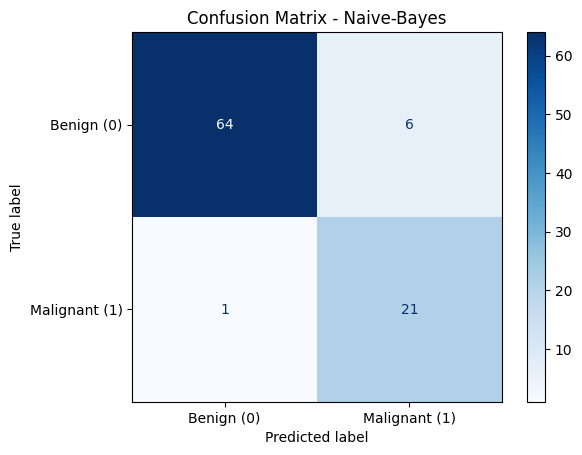

Classification Report for Naive-Bayes:
               precision    recall  f1-score   support

   Benign (0)       0.98      0.91      0.95        70
Malignant (1)       0.78      0.95      0.86        22

     accuracy                           0.92        92
    macro avg       0.88      0.93      0.90        92
 weighted avg       0.94      0.92      0.93        92

--------------------------------------------------


In [28]:

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f"Confusion Matrix for {name}:")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malignant (1)"])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"]))
    print("-" * 50)


In [29]:
# Save all trained models to joblib files
import joblib

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    joblib.dump(pipe, f'{name.lower()}_model.joblib')
    print(f"Saved {name} model to {name.lower()}_model.joblib")

Saved DecisionTree model to decisiontree_model.joblib
Saved KNN model to knn_model.joblib
Saved Naive-Bayes model to naive-bayes_model.joblib


In [30]:
# Save only the best KNN model and its scaler
import joblib

# Create and fit the best KNN pipeline
KNNcancermodel = Pipeline([
    ('scalar', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])
KNNcancermodel.fit(X_train, y_train)
joblib.dump(KNNcancermodel, 'KNNcancermodel.joblib')
print(f"Saved best KNN model (K={best_k}) to KNNcancermodel.joblib")

# Save the scaler used for KNN separately if needed
knn_scaler = StandardScaler().fit(X_train)
joblib.dump(knn_scaler, 'knn_scaler.joblib')
print("Saved KNN scaler to knn_scaler.joblib")

Saved best KNN model (K=12) to KNNcancermodel.joblib
Saved KNN scaler to knn_scaler.joblib
